In [1]:
import numpy as np
from joblib import load
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import regularizers
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
import joblib
import numpy as np
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import load_model
from collections import Counter
from xgboost import XGBClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline

In [81]:
data_train = pd.read_csv("KDDTrain+.txt", header=None)
data_test = pd.read_csv("KDDTest+.txt", header=None)

columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])
data_train.columns = columns

In [82]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])

In [83]:
data_train.columns = columns
data_test.columns = columns

In [84]:
attack_mapping = {
    'normal': 'normal',
    'neptune': 'DoS',
    'smurf': 'DoS',
    'back': 'DoS',
    'teardrop': 'DoS',
    'pod': 'DoS',
    'land': 'DoS',
    'apache2': 'DoS',
    'mailbomb': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',
    'nuked': 'DoS',
    'worm': 'DoS',

    'ipsweep': 'Probe',
    'portsweep': 'Probe',
    'nmap': 'Probe',
    'satan': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',
    'xsnoop': 'Probe',
    'snmpgetattack': 'Probe',
    'snmpguess': 'Probe',
    'httptunnel': 'Probe',

    'warezclient': 'R2L',
    'guess_passwd': 'R2L',
    'ftp_write': 'R2L',
    'multihop': 'R2L',
    'imap': 'R2L',
    'warezmaster': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'sendmail': 'R2L',
    'secrect': 'R2L',

    'rootkit': 'U2R',
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R',
    'named': 'U2R',
    'xlock': 'U2R'
}

unmapped_attacks = set(data_train['outcome'].unique()) - set(attack_mapping.keys())
if unmapped_attacks:
    print(f"Warning: The following attack types in 'outcome' are not in the provided mapping: {unmapped_attacks}. They will be mapped to 'Other_Attack'.")
    for attack in unmapped_attacks:
        attack_mapping[attack] = 'Other_Attack'

data_train['attack_class'] = data_train['outcome'].map(attack_mapping)
data_test['attack_class'] = data_test['outcome'].map(attack_mapping)

print("\nValue counts for 'attack_class' after mapping:")
print(data_train['attack_class'].value_counts())
print("\nValue counts for 'attack_class' in test set after mapping:")
print(data_test['attack_class'].value_counts())


Value counts for 'attack_class' after mapping:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Value counts for 'attack_class' in test set after mapping:
attack_class
normal    9711
DoS       7460
Probe     3067
R2L       2213
U2R         93
Name: count, dtype: int64


In [85]:
data_train = pd.get_dummies(
    data_train,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)
data_test = pd.get_dummies(
    data_test,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)

In [86]:
data_train, data_test = data_train.align(
    data_test,
    join='left',
    axis=1,
    fill_value=0
)

In [87]:
data_train_final=data_train.copy()
data_test_final=data_test.copy()

In [88]:
le = LabelEncoder()

data_train_final['attack_class'] = le.fit_transform(data_train_final['attack_class'])
data_test_final['attack_class'] = le.transform(data_test_final['attack_class'])

In [89]:
X_train = data_train_final.drop(['attack_class', 'outcome'], axis=1)
y_train = data_train_final['attack_class']
X_test = data_test_final.drop(['attack_class', 'outcome'], axis=1)
y_test = data_test_final['attack_class']

In [90]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'DoS': np.int64(0), 'Probe': np.int64(1), 'R2L': np.int64(2), 'U2R': np.int64(3), 'normal': np.int64(4)}


In [92]:
xgb_model = load('xgb_model_standalone.pkl')
catboost_model = load('catboost_model_standalone.pkl')
adaboost_model = load('adaboost_model_standalone.pkl')
randomforest_model = load('random_forest_smote_model.joblib')

svm_model=load('svm_model.pkl')
nb_model=load('naive_bayes_model.pkl')
knn_model=load('knn_model.pkl')
logistic_model=load('logistic_regression_model.pkl')
stand_scaler=load('standard_scaler.pkl')

mlp_model=load_model('mlp_ids_model.keras')
cnn_model = load_model('cnn_ids_model.keras')

scaler =load(
    "scaler.pkl"
)

le =load(
    "label_encoder.pkl"
)

encoder = load_model(
    "encoder_model.keras"
)

autoencoder = load_model(
    "autoencoder_model.keras"
)

xgb_auto_model = XGBClassifier()

xgb_auto_model.load_model(
    "xgb_model.json"
)
xgb_model_robust = XGBClassifier()

xgb_model_robust.load_model(
    "robust_xgb_model.json"
)

print("ALL MODELS LOADED SUCCESSFULLY!")


ALL MODELS LOADED SUCCESSFULLY!


In [93]:
X_test_scaled = scaler.transform(X_test)

In [14]:
X_test_scaled = X_test_scaled.astype(np.float32)
X_test_encoded = encoder.predict(
    X_test_scaled
)
X_test_encoded = X_test_encoded.astype(np.float32)

X_test_fused = np.concatenate(

    [
        X_test_scaled,
        X_test_encoded
    ],

    axis=1
)

print(X_test_fused.shape)

705/705 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step
(22544, 168)


In [15]:
y_pred = xgb_auto_model.predict(
    X_test_fused
)
hybrid_results = {}
hybrid_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average='weighted'),
    "Recall": recall_score(y_test, y_pred, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred, average='weighted'),
    "Macro F1": f1_score(y_test, y_pred, average='macro'),
    "Classification Report": classification_report(y_test, y_pred),
    "Confusion Matrix": confusion_matrix(y_test, y_pred)
}

print("\n====================================")
print("Hybrid MODEL RESULTS")
print("====================================")

print(f"Accuracy : {hybrid_results['Accuracy']:.4f}")
print(f"Precision: {hybrid_results['Precision']:.4f}")
print(f"Recall   : {hybrid_results['Recall']:.4f}")
print(f"F1 Score : {hybrid_results['F1 Score']:.4f}")
print(f"Macro F1 : {hybrid_results['Macro F1']:.4f}")

print("\nClassification Report:\n")
print(hybrid_results["Classification Report"])

print("\nConfusion Matrix:\n")
print(hybrid_results["Confusion Matrix"])


Hybrid MODEL RESULTS
Accuracy : 0.8252
Precision: 0.8507
Recall   : 0.8252
F1 Score : 0.8142
Macro F1 : 0.6838

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.84      0.90      7460
           1       0.86      0.70      0.77      3067
           2       0.95      0.33      0.49      2213
           3       0.40      0.45      0.42        93
           4       0.74      0.97      0.84      9711

    accuracy                           0.83     22544
   macro avg       0.78      0.66      0.68     22544
weighted avg       0.85      0.83      0.81     22544


Confusion Matrix:

[[6256  138    1    2 1063]
 [ 166 2134    6   14  747]
 [   0   16  729   48 1420]
 [   0    6   31   42   14]
 [  67  198    3    0 9443]]


In [16]:
y_pred = xgb_model_robust.predict(
    X_test_fused
)
robust_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average='weighted'),
    "Recall": recall_score(y_test, y_pred, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred, average='weighted'),
    "Macro F1": f1_score(y_test, y_pred, average='macro'),
    "Classification Report": classification_report(y_test, y_pred),
    "Confusion Matrix": confusion_matrix(y_test, y_pred),
}

print("\n====================================")
print("ROBUST MODEL RESULTS")
print("====================================")

print(f"Accuracy : {robust_results['Accuracy']:.4f}")
print(f"Precision: {robust_results['Precision']:.4f}")
print(f"Recall   : {robust_results['Recall']:.4f}")
print(f"F1 Score : {robust_results['F1 Score']:.4f}")
print(f"Macro F1 : {robust_results['Macro F1']:.4f}")

print("\nClassification Report:\n")
print(robust_results["Classification Report"])

print("\nConfusion Matrix:\n")
print(robust_results["Confusion Matrix"])


ROBUST MODEL RESULTS
Accuracy : 0.8109
Precision: 0.8409
Recall   : 0.8109
F1 Score : 0.8016
Macro F1 : 0.6906

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.81      0.88      7460
           1       0.87      0.63      0.73      3067
           2       0.92      0.37      0.53      2213
           3       0.45      0.53      0.49        93
           4       0.72      0.97      0.83      9711

    accuracy                           0.81     22544
   macro avg       0.79      0.66      0.69     22544
weighted avg       0.84      0.81      0.80     22544


Confusion Matrix:

[[6032   29   44    2 1353]
 [ 166 1944    2   11  944]
 [   0   50  815   47 1301]
 [   0   13   18   49   13]
 [  67  200    4    0 9440]]


In [17]:
ensemble_results = {}

for model in [xgb_model, catboost_model, adaboost_model]:

    y_pred = model.predict(X_test)

    ensemble_results[model.__class__.__name__] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "Macro F1": f1_score(y_test, y_pred, average='macro'),
        "Classification Report": classification_report(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

    print(f"\nModel: {model.__class__.__name__}")
    print(f"Accuracy: {ensemble_results[model.__class__.__name__]['Accuracy']:.4f}")
    print(f"Precision: {ensemble_results[model.__class__.__name__]['Precision']:.4f}")
    print(f"Recall: {ensemble_results[model.__class__.__name__]['Recall']:.4f}")
    print(f"F1 Score: {ensemble_results[model.__class__.__name__]['F1 Score']:.4f}")
    print(f"Macro F1 Score: {ensemble_results[model.__class__.__name__]['Macro F1']:.4f}")

    print(classification_report(y_test, y_pred))


Model: XGBClassifier
Accuracy: 0.8149
Precision: 0.8418
Recall: 0.8149
F1 Score: 0.8036
Macro F1 Score: 0.6715
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      7460
           1       0.84      0.59      0.69      3067
           2       0.94      0.35      0.51      2213
           3       0.39      0.45      0.42        93
           4       0.73      0.97      0.83      9711

    accuracy                           0.81     22544
   macro avg       0.77      0.64      0.67     22544
weighted avg       0.84      0.81      0.80     22544


Model: CatBoostClassifier
Accuracy: 0.8044
Precision: 0.8265
Recall: 0.8044
F1 Score: 0.7935
Macro F1 Score: 0.6690
              precision    recall  f1-score   support

           0       0.96      0.81      0.88      7460
           1       0.80      0.59      0.68      3067
           2       0.86      0.36      0.51      2213
           3       0.45      0.44      0.45        93
           

## Linear Models

In [18]:
stand_scaler=load('standard_scaler.pkl')

In [19]:
if 'level' in X_test.columns:
    X_test_lin = X_test.drop(columns=['level'])

In [20]:
print("Scaler expects:", len(stand_scaler.feature_names_in_))
print("X_test has:", len(X_test_lin.columns))
print("Extra:", set(X_test_lin.columns) - set(stand_scaler.feature_names_in_))

Scaler expects: 38
X_test has: 119
Extra: {'service_auth', 'service_uucp', 'service_remote_job', 'service_ftp', 'service_uucp_path', 'service_netbios_ns', 'service_Z39_50', 'service_bgp', 'service_pm_dump', 'flag_S0', 'service_X11', 'service_netbios_dgm', 'service_netstat', 'service_kshell', 'protocol_type_tcp', 'service_discard', 'service_red_i', 'service_private', 'service_gopher', 'service_ldap', 'service_echo', 'service_imap4', 'service_eco_i', 'service_shell', 'service_link', 'service_tim_i', 'service_daytime', 'service_domain', 'flag_SF', 'service_telnet', 'service_iso_tsap', 'service_efs', 'service_pop_3', 'service_time', 'service_whois', 'service_systat', 'service_ecr_i', 'service_mtp', 'service_supdup', 'service_urh_i', 'protocol_type_udp', 'service_harvest', 'service_rje', 'flag_REJ', 'service_vmnet', 'service_tftp_u', 'service_urp_i', 'service_pop_2', 'service_other', 'service_courier', 'flag_S1', 'flag_SH', 'service_ssh', 'service_hostnames', 'service_printer', 'service_nnt

In [21]:
numerical_cols = X_test.select_dtypes(include=np.number).columns
X_test_scaled_linear = X_test_lin.copy()

X_test_scaled_linear[stand_scaler.feature_names_in_] = (
    stand_scaler.transform(
        X_test_scaled_linear[stand_scaler.feature_names_in_]
    )
)

In [22]:
print(X_test_scaled_linear.shape)
print(knn_model.n_features_in_)

(22544, 119)
119


In [49]:
linear_results = {}

for model in [knn_model, logistic_model, svm_model, nb_model]:

    y_pred = model.predict(X_test_scaled_linear)

    linear_results[model.__class__.__name__] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "Macro F1": f1_score(y_test, y_pred, average='macro'),
        "Classification Report": classification_report(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

    print(f"\nModel: {model.__class__.__name__}")
    print(f"Accuracy: {linear_results[model.__class__.__name__]['Accuracy']:.4f}")
    print(f"Precision: {linear_results[model.__class__.__name__]['Precision']:.4f}")
    print(f"Recall: {linear_results[model.__class__.__name__]['Recall']:.4f}")
    print(f"F1 Score: {linear_results[model.__class__.__name__]['F1 Score']:.4f}")
    print(f"Macro F1 Score: {linear_results[model.__class__.__name__]['Macro F1']:.4f}")
    print(classification_report(y_test, y_pred))


Model: KNeighborsClassifier
Accuracy: 0.7689
Precision: 0.8120
Recall: 0.7689
F1 Score: 0.7355
Macro F1 Score: 0.5663
              precision    recall  f1-score   support

           0       0.96      0.82      0.88      7460
           1       0.84      0.54      0.66      3067
           2       0.89      0.05      0.10      2213
           3       0.61      0.29      0.39        93
           4       0.67      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.80      0.53      0.57     22544
weighted avg       0.81      0.77      0.74     22544


Model: LogisticRegression
Accuracy: 0.7633
Precision: 0.7940
Recall: 0.7633
F1 Score: 0.7406
Macro F1 Score: 0.5663
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      7460
           1       0.87      0.58      0.70      3067
           2       0.82      0.14      0.24      2213
           3       0.30      0.23      0.26        93
    

### MLP and CNN

In [101]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_test_scaled_mlp = scaler.fit_transform(X_test)

In [94]:
X_test_scaled = scaler.transform(X_test)

In [95]:
print("Scaler expects:")
print(scaler.feature_names_in_)

print("\nCurrent X_test columns:")
print(X_test.columns)

print("\nMissing columns:")
print(set(scaler.feature_names_in_) - set(X_test.columns))

Scaler expects:
['duration' 'src_bytes' 'dst_bytes' 'land' 'wrong_fragment' 'urgent' 'hot'
 'num_failed_logins' 'logged_in' 'num_compromised' 'root_shell'
 'su_attempted' 'num_root' 'num_file_creations' 'num_shells'
 'num_access_files' 'num_outbound_cmds' 'is_host_login' 'is_guest_login'
 'count' 'srv_count' 'serror_rate' 'srv_serror_rate' 'rerror_rate'
 'srv_rerror_rate' 'same_srv_rate' 'diff_srv_rate' 'srv_diff_host_rate'
 'dst_host_count' 'dst_host_srv_count' 'dst_host_same_srv_rate'
 'dst_host_diff_srv_rate' 'dst_host_same_src_port_rate'
 'dst_host_srv_diff_host_rate' 'dst_host_serror_rate'
 'dst_host_srv_serror_rate' 'dst_host_rerror_rate'
 'dst_host_srv_rerror_rate' 'level' 'protocol_type_tcp'
 'protocol_type_udp' 'service_X11' 'service_Z39_50' 'service_aol'
 'service_auth' 'service_bgp' 'service_courier' 'service_csnet_ns'
 'service_ctf' 'service_daytime' 'service_discard' 'service_domain'
 'service_domain_u' 'service_echo' 'service_eco_i' 'service_ecr_i'
 'service_efs' 'service

In [96]:
from tensorflow.keras.utils import to_categorical
X_test_mlp = X_test_scaled.astype(np.float32)
y_test_mlp = to_categorical(
    y_test
)


In [102]:
y_pred_probs = mlp_model.predict(
    X_test_mlp
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

y_true = np.argmax(
    y_test_mlp,
    axis=1
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

print("\n====================================")
print("MLP IDS RESULTS")
print("====================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_true,
        y_pred
    )
)
mlp_accuracy = accuracy_score(y_true, y_pred)
mlp_precision = precision_score(y_true, y_pred, average='weighted')
mlp_recall = recall_score(y_true, y_pred, average='weighted')
mlp_f1 = f1_score(y_true, y_pred, average='weighted')
mlp_macro_f1 = f1_score(y_true, y_pred, average='macro')
mlp_class_report = classification_report(y_true, y_pred)
mlp_confusion_matrix = confusion_matrix(y_true, y_pred)

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

MLP IDS RESULTS
Accuracy : 0.8011
Precision: 0.8141
Recall   : 0.8011
F1 Score : 0.7892
Macro F1 : 0.6482

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      7460
           1       0.74      0.70      0.72      3067
           2       0.83      0.29      0.42      2213
           3       0.30      0.55      0.39        93
           4       0.75      0.93      0.83      9711

    accuracy                           0.80     22544
   macro avg       0.71      0.66      0.65     22544
weighted avg       0.81      0.80      0.79     22544


Confusion Matrix:

[[6222   40   35   18 1145]
 [ 181 2134   84   53  615]
 [ 206   77  631   46 1253]
 [   0   22    5   51   15]
 [  65  620    5    0 9021]]


In [27]:
results_mlp={}
results_mlp = {
    "Accuracy": mlp_accuracy,
    "Precision": mlp_precision,
    "Recall": mlp_recall,
    "F1 Score": mlp_f1,
    "Macro F1": mlp_macro_f1,
    "Classification Report": mlp_class_report,
    "Confusion Matrix": mlp_confusion_matrix
}

In [38]:
data_train_final.drop('level', axis=1, inplace=True)
data_test_final.drop('level', axis=1, inplace=True)

In [39]:
X_train = data_train_final.drop(['attack_class', 'outcome'], axis=1)
y_train = data_train_final['attack_class']
X_test = data_test_final.drop(['attack_class', 'outcome'], axis=1)
y_test = data_test_final['attack_class']

In [40]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.0)

X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)

In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_test_scaled = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

In [43]:
cnn_model = load_model("cnn_ids_model.keras")

In [44]:
y_test.head()

0    0
1    0
2    4
3    1
4    1
Name: attack_class, dtype: int64

In [45]:
y_pred = cnn_model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))
print("Accuracy Score:", accuracy_score(y_test, y_pred_classes))
print("Precision Score:", precision_score(y_test, y_pred_classes, average='weighted'))
print("Recall Score:", recall_score(y_test, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_classes, average='weighted'))

705/705 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87      7460
           1       0.81      0.43      0.57      3067
           2       0.95      0.20      0.33      2213
           3       1.00      0.06      0.12        93
           4       0.65      0.96      0.78      9711

    accuracy                           0.75     22544
   macro avg       0.88      0.49      0.53     22544
weighted avg       0.81      0.75      0.73     22544

Confusion Matrix:
[[5859   13    0    0 1588]
 [ 158 1332    6    0 1571]
 [   0    0  442    0 1771]
 [   0    4   10    6   73]
 [  52  294    7    0 9358]]
Accuracy Score: 0.7539478353442157
Precision Score: 0.807878005845972
Recall Score: 0.7539478353442157
F1 Score: 0.7313785900289689


In [57]:
result_cnn = {
    "Accuracy": accuracy_score(y_test, y_pred_classes),
    "Precision": precision_score(y_test, y_pred_classes, average='weighted'),
    "Recall": recall_score(y_test, y_pred_classes, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_classes, average='weighted'),
    "Macro F1": f1_score(y_test, y_pred_classes, average='macro'),
    "Classification Report": classification_report(y_test, y_pred_classes),
    "Confusion Matrix": confusion_matrix(y_test, y_pred_classes)
}

In [60]:
final_results = []

final_results.append({
    "Model": "CNN",
    "Accuracy": result_cnn["Accuracy"],
    "Precision": result_cnn["Precision"],
    "Recall": result_cnn["Recall"],
    "F1 Score": result_cnn["F1 Score"],
    "Macro F1": result_cnn["Macro F1"]
})

final_results.append({
    "Model": "MLP",
    "Accuracy": results_mlp["Accuracy"],
    "Precision": results_mlp["Precision"],
    "Recall": results_mlp["Recall"],
    "F1 Score": results_mlp["F1 Score"],
    "Macro F1": results_mlp["Macro F1"]
})

for model_name, metrics in linear_results.items():
    final_results.append({
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1 Score": metrics["F1 Score"],
        "Macro F1": metrics["Macro F1"]
    })

for model_name, metrics in ensemble_results.items():
    final_results.append({
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1 Score": metrics["F1 Score"],
        "Macro F1": metrics["Macro F1"]
    })

final_results.append({
    "Model": "Robust Autoencoder",
    "Accuracy": robust_results["Accuracy"],
    "Precision": robust_results["Precision"],
    "Recall": robust_results["Recall"],
    "F1 Score": robust_results["F1 Score"],
    "Macro F1": robust_results["Macro F1"]
})

final_results.append({
    "Model": "Hybrid XGBoost + DAE",
    "Accuracy": hybrid_results["Accuracy"],
    "Precision": hybrid_results["Precision"],
    "Recall": hybrid_results["Recall"],
    "F1 Score": hybrid_results["F1 Score"],
    "Macro F1": hybrid_results["Macro F1"]
})

results_df = pd.DataFrame(final_results)

print(results_df)

                   Model  Accuracy  Precision    Recall  F1 Score  Macro F1
0                    CNN  0.753948   0.807878  0.753948  0.731379  0.532111
1                    MLP  0.801056   0.814109  0.801056  0.789203  0.648193
2   KNeighborsClassifier  0.768852   0.811998  0.768852  0.735460  0.566269
3     LogisticRegression  0.763307   0.793971  0.763307  0.740604  0.566346
4                    SVC  0.755633   0.811691  0.755633  0.730967  0.549435
5             GaussianNB  0.495076   0.666559  0.495076  0.506319  0.347137
6          XGBClassifier  0.814851   0.841814  0.814851  0.803606  0.671493
7     CatBoostClassifier  0.804427   0.826539  0.804427  0.793546  0.669034
8     AdaBoostClassifier  0.704888   0.690481  0.704888  0.676115  0.461436
9     Robust Autoencoder  0.810859   0.840913  0.810859  0.801582  0.690647
10  Hybrid XGBoost + DAE  0.825231   0.850714  0.825231  0.814205  0.683765


In [53]:
results_df = pd.DataFrame(final_results)

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "Macro F1"]

results_df[metric_cols] = (
    results_df[metric_cols]
    .multiply(100)
    .round(2)
)

print(results_df)

                   Model  Accuracy  Precision  Recall  F1 Score  Macro F1
0                    CNN     75.39      80.79   75.39     73.14     53.21
1                    MLP     80.11      81.41   80.11     78.92     64.82
2   KNeighborsClassifier     76.89      81.20   76.89     73.55     56.63
3     LogisticRegression     76.33      79.40   76.33     74.06     56.63
4                    SVC     75.56      81.17   75.56     73.10     54.94
5             GaussianNB     49.51      66.66   49.51     50.63     34.71
6          XGBClassifier     81.49      84.18   81.49     80.36     67.15
7     CatBoostClassifier     80.44      82.65   80.44     79.35     66.90
8     AdaBoostClassifier     70.49      69.05   70.49     67.61     46.14
9     Robust Autoencoder     81.09      84.09   81.09     80.16     69.06
10  Hybrid XGBoost + DAE     82.52      85.07   82.52     81.42     68.38


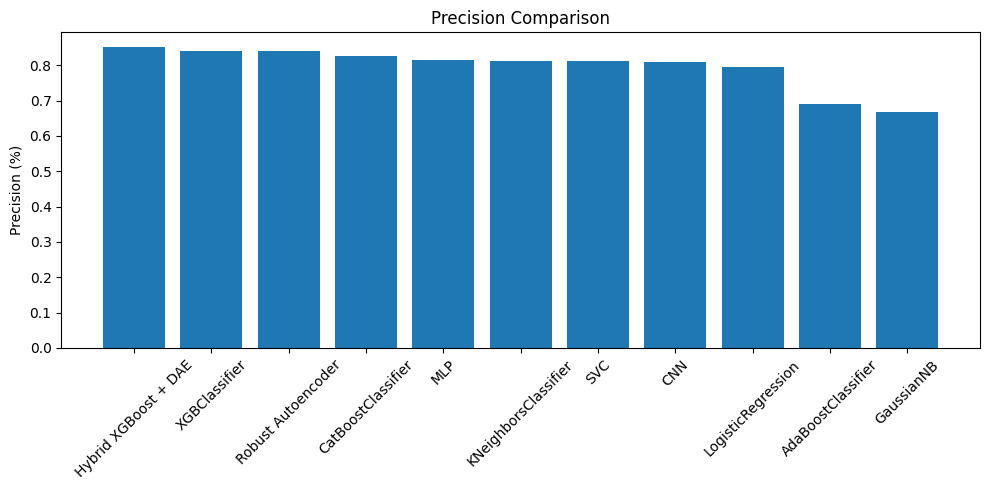

In [108]:
precision_order = results_df.sort_values(by="Precision", ascending=False)
plt.figure(figsize=(10,5))
plt.bar(precision_order["Model"], precision_order["Precision"])
plt.title("Precision Comparison")
plt.ylabel("Precision (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

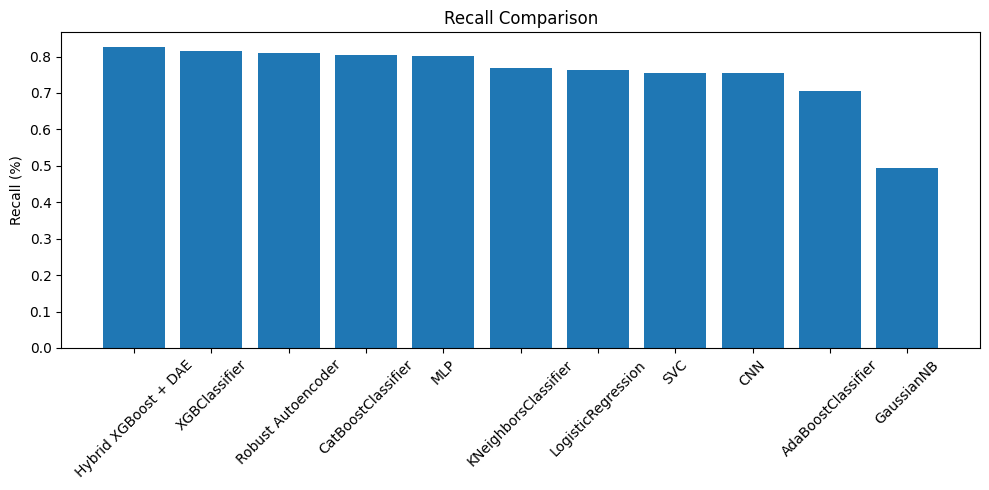

In [107]:
recall_order = results_df.sort_values(by="Recall", ascending=False)
plt.figure(figsize=(10,5))
plt.bar(recall_order["Model"], recall_order["Recall"])
plt.title("Recall Comparison")
plt.ylabel("Recall (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

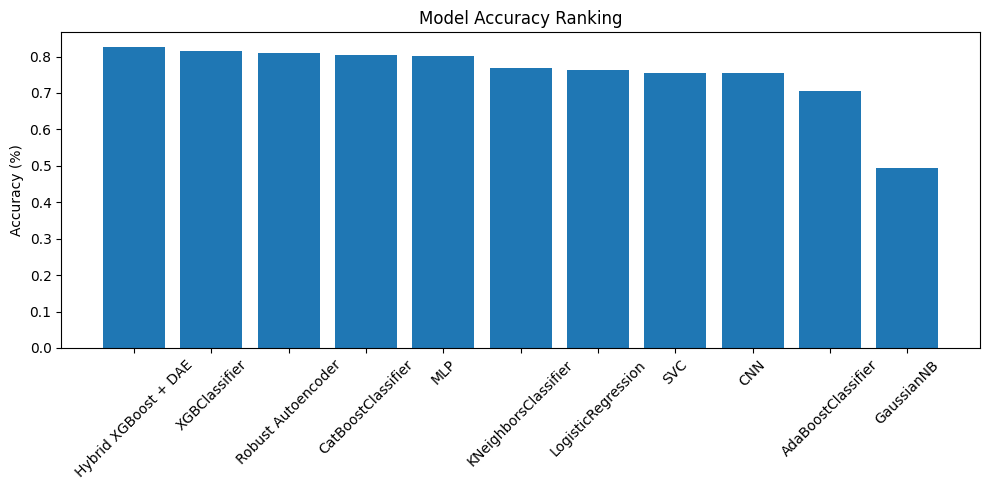

In [62]:
ranked = results_df.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(ranked["Model"], ranked["Accuracy"])

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Ranking")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

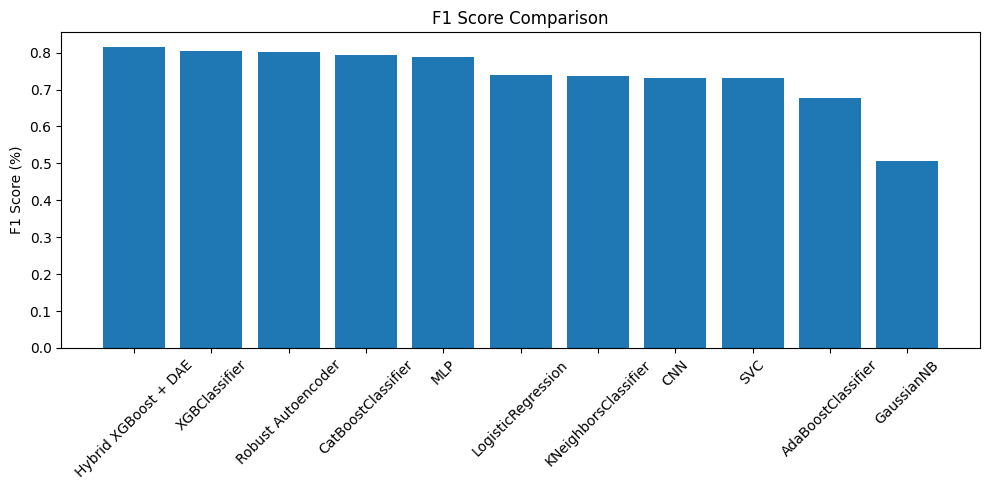

In [109]:
f1_order = results_df.sort_values(by="F1 Score", ascending=False)
plt.figure(figsize=(10,5))
plt.bar(f1_order["Model"], f1_order["F1 Score"])
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

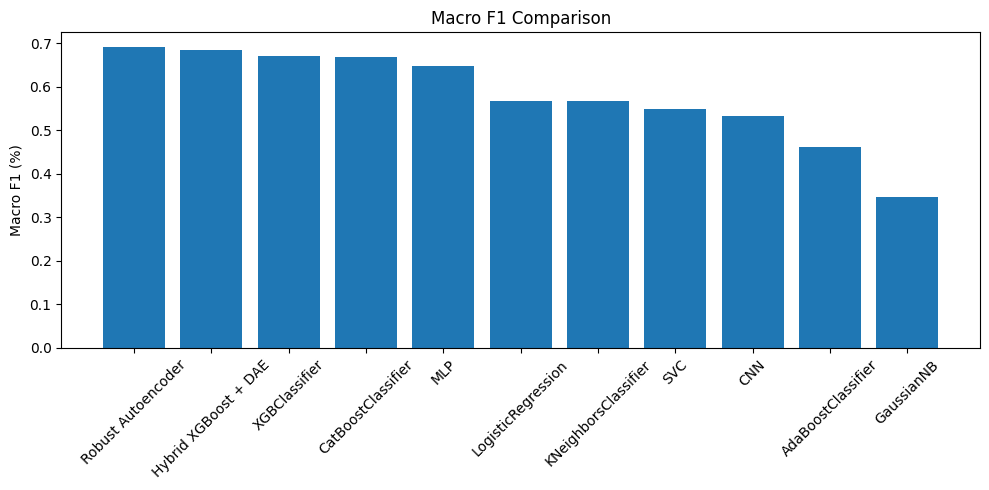

In [110]:
macro_f1_order = results_df.sort_values(by="Macro F1", ascending=False)
plt.figure(figsize=(10,5))
plt.bar(macro_f1_order["Model"], macro_f1_order["Macro F1"])
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1 (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

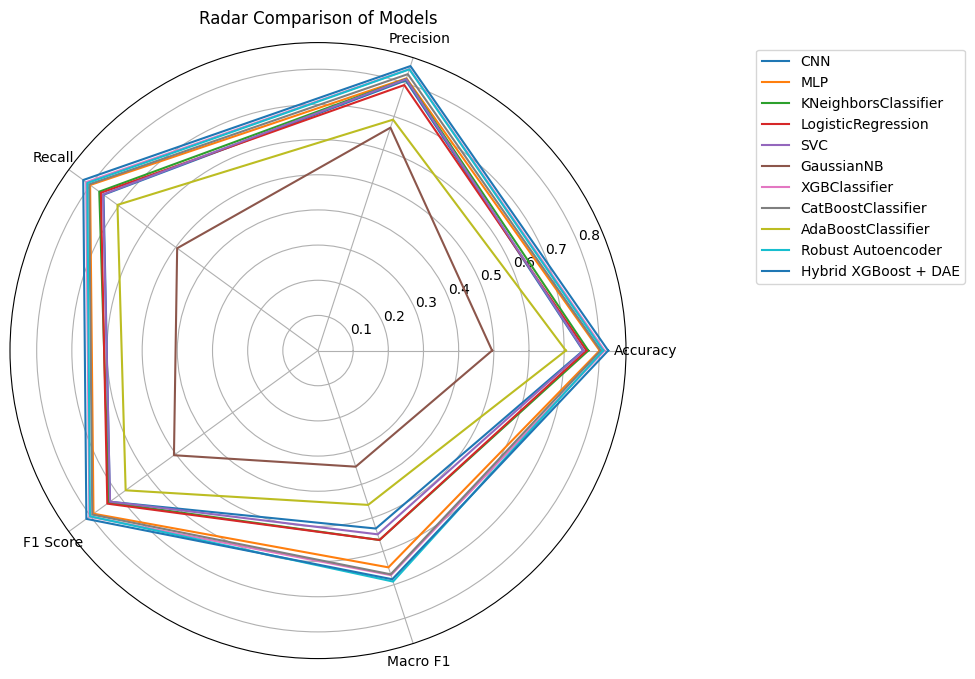

In [63]:
import numpy as np

metrics = metric_cols

angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
).tolist()

angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for _, row in results_df.iterrows():

    values = [row[m] for m in metrics]
    values += values[:1]

    ax.plot(angles, values, label=row["Model"])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

plt.legend(
    bbox_to_anchor=(1.2,1)
)

plt.title("Radar Comparison of Models")
plt.show()

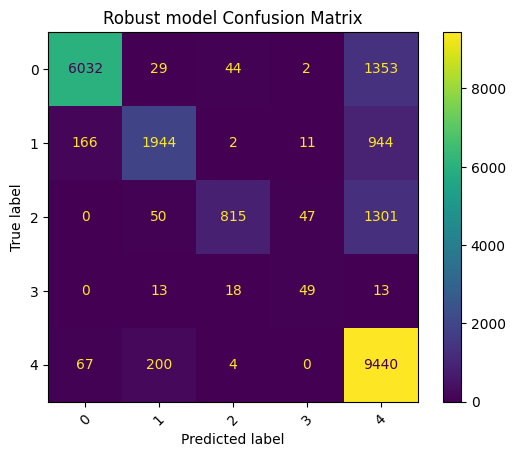

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = robust_results["Confusion Matrix"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    xticks_rotation=45
)

plt.title("Robust model Confusion Matrix")
plt.show()